In [1]:
import sys
import numpy as np
import matplotlib.pyplot as plt
sys.path.insert(0, '..')

from qiskit_aer import AerSimulator
from solver.quantum_solver.qaoa_solver.qaoa_optimizer import QAOALocalOptimizer

# Problème max-cut 5 qubits
ising_problem = {
    'linear':    {0: 0, 1: 0, 2: 0, 3: 0, 4: 0},
    'quadratic': {(0,4): 1, (1,4): 1, (2,4): 1, (3,4): 1}
}

sim = AerSimulator()
print("Import OK")

Import OK


In [2]:
# Test pour différentes profondeurs p
results = {}

for p in range(1, 7):
    exp_values = []
    for _ in range(5):  # 5 rounds par profondeur
        optimizer = QAOALocalOptimizer(
            simulator=sim,
            gamma_bounds=(0, np.pi),
            beta_bounds=(0, np.pi),
            p=p,
            shots=1024,
            opt_method='COBYLA'
        )
        exp_val, best_sol, angles = optimizer.optimize(ising_problem, p=p)
        exp_values.append(exp_val)
    results[p] = exp_values
    print(f"p={p} : mean={np.mean(exp_values):.4f}, min={np.min(exp_values):.4f}")

p=1 : mean=-0.0211, min=-0.0723
p=2 : mean=-0.3230, min=-0.6035
p=3 : mean=-0.3742, min=-0.7305
p=4 : mean=-0.3863, min=-0.5840
p=5 : mean=-0.5293, min=-0.7246
p=6 : mean=-0.6691, min=-0.9180


/var/folders/kz/chbwwwss3lx7f4lr1km4nxgm0000gn/T/ipykernel_4979/4107612813.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([results[p] for p in range(1, 7)], labels=[f'p={p}' for p in range(1, 7)])


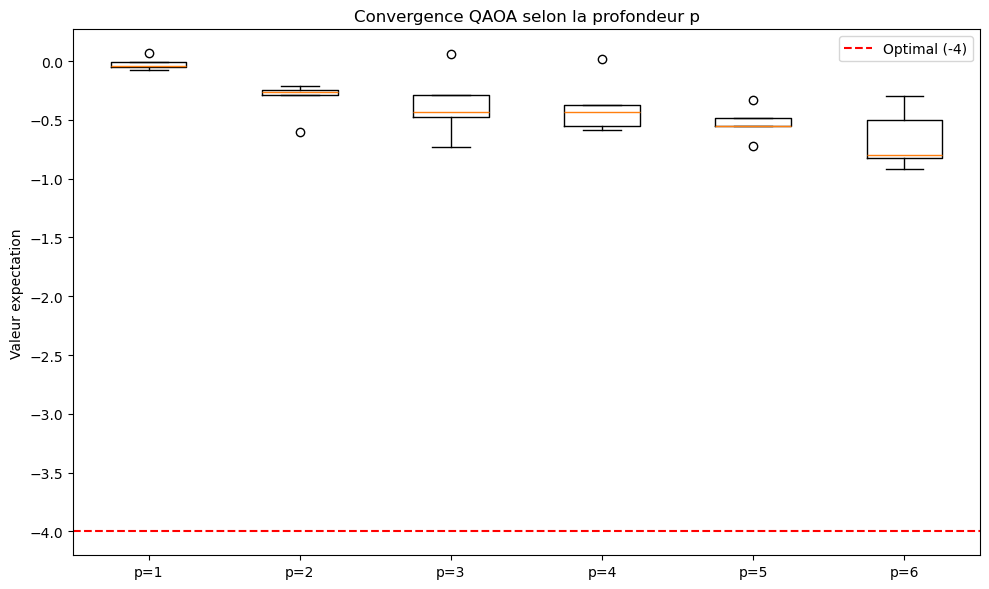

In [3]:
plt.figure(figsize=(10, 6))
plt.boxplot([results[p] for p in range(1, 7)], labels=[f'p={p}' for p in range(1, 7)])
plt.axhline(y=-4, color='red', linestyle='--', label='Optimal (-4)')
plt.ylabel('Valeur expectation')
plt.title('Convergence QAOA selon la profondeur p')
plt.legend()
plt.tight_layout()
plt.show()